In [ ]:
# 1. Download the inference results if not already downloaded.

!wget "https://surfdrive.surf.nl/files/index.php/s/G8XWW8On5MWhtCk/download?path=%2FInference&files=inference_results_ToyExample-v2_Cologne-v1_CologneBonnDusseldorf-v1.csv" -qO inference_results.csv

# 2. Model checkpoints should be in ../outputs/Cologne-v1/vdn_rnn/

In [1]:
import yaml
import jax
import jaxmarl

import numpy as np
import matplotlib.pyplot as plt
from rollout_data_generator import RolloutDataGenerator
from heuristic_rollout_data_generator import HeuristicRolloutDataGenerator
from plotter import RolloutPlotter, plot_action_stats

## MARL agent

In [ ]:
ENV_NAME = 'Cologne-v1'
ALG = 'vdn_rnn'
env = jaxmarl.make("road_env", map_name=ENV_NAME)
rdg = RolloutDataGenerator(ENV_NAME, ALG, test_num_envs=1_000)
rp = RolloutPlotter(env)

key = jax.random.PRNGKey(87)
episode_data = rdg.generate_rollout_data(key, verbose=True)

## Heuristic

In [2]:
config_path = "../experiments/config/heuristics/best_parameters/cologne_v1_heuristic.yaml"
config = yaml.safe_load(open(config_path, 'r'))
env = jaxmarl.make("road_env", map_name=config['map'])

rdg = HeuristicRolloutDataGenerator(config)
rp = RolloutPlotter(env)
key = jax.random.PRNGKey(87)
num_rollouts = 1000
episode_data = rdg.generate_rollout_data(key, num_rollouts, verbose=True)

action                              (1000, 50, 60)
applied_actions                     (1000, 50, 60)
budget_constraints_applied          (1000, 50)
budget_remaining                    (1000, 51)
edge_beliefs                        (1000, 51, 60, 5)
edge_observations                   (1000, 51, 60)
edge_states                         (1000, 51, 60)
episode_cost                        (1000, 1)
forced_replace_constraint_applied   (1000, 50)
maintenance_reward                  (1000, 50)
reward                              (1000, 50)
terminal_reward                     (1000, 50)
timesteps                           (1000, 51)
total_travel_time                   (1000, 50)
traffic_volumes                     (1000, 50, 60)
travel_time_reward                  (1000, 50)
travel_times                        (1000, 50, 60)


## Analysing Multiple Episodes

### What is the distribution of returns across episodes?


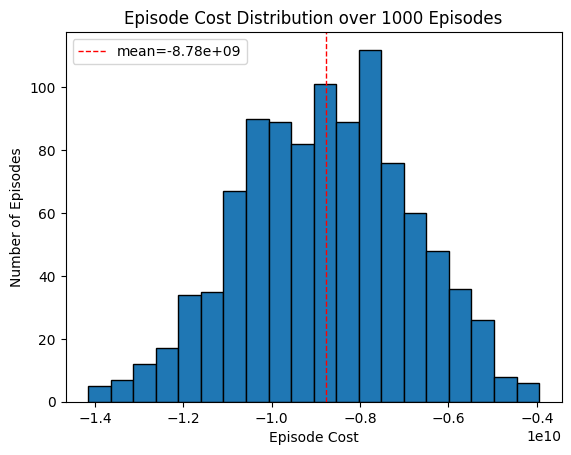

In [3]:
plt.hist(episode_data['episode_cost'].flatten(), edgecolor='black', bins=20)
_mean = np.mean(episode_data['episode_cost'])
plt.axvline(_mean, label=f'mean={_mean:.2e}', color='red', linestyle='dashed', linewidth=1)
plt.xlabel('Episode Cost')
plt.ylabel('Number of Episodes')
plt.title(f'Episode Cost Distribution over {episode_data["episode_cost"].shape[0]} Episodes')
plt.legend()
plt.show()

#### How often are budget constraints applied at timestep t?
#### How often are forced replacement actions applied at timestep t?

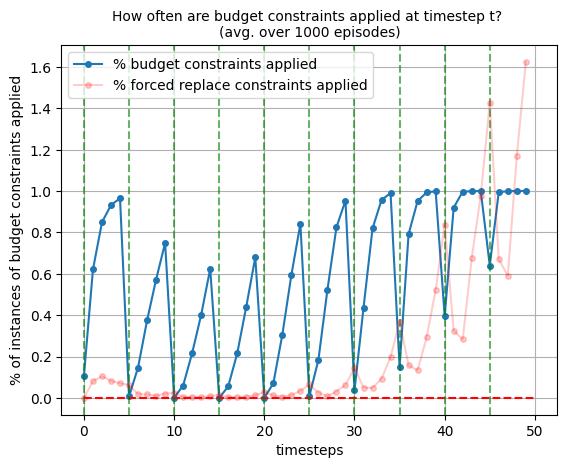

In [4]:
plt.plot(episode_data['budget_constraints_applied'].astype(int).mean(axis=0), '-o', markersize=4, label='% budget constraints applied')
plt.hlines(0, xmin=0, xmax=50, colors='red', linestyles='dashed')

for t in range(episode_data['budget_constraints_applied'].shape[1]):
    if t % 5 == 0:
        plt.axvline(t, color="green", linestyle="--", alpha=0.6)

plt.plot(episode_data['forced_replace_constraint_applied'].astype(int).mean(axis=0), '-o', markersize=4, color='red', alpha=0.2, label='% forced replace constraints applied')

plt.xlabel('timesteps')
plt.ylabel('% of instances of budget constraints applied')
plt.title(f'How often are budget constraints applied at timestep t? \n(avg. over {episode_data["budget_constraints_applied"].shape[0]} episodes)', fontsize=10)
plt.legend()
plt.grid()
plt.show()

#### What is the average distribution of `applied_actions` per period?

In [5]:
l = 0
period = env.env.budget_renewal_interval
horizon = env.env.max_timesteps
routine_inspections_per_period = []
major_inspections_per_period = []
minor_repairs_per_period = []
major_repairs_per_period = []
replacements_per_period = []
for m in range(period, horizon + period, period):

    # number of routine inspections
    num_routine_inspections = np.mean(episode_data['applied_actions'][:, l:m, :] == 0)
    routine_inspections_per_period.append(num_routine_inspections)

    # number of major inspections
    num_major_inspections = np.mean(episode_data['applied_actions'][:, l:m, :] == 1)
    major_inspections_per_period.append(num_major_inspections)

    # number of minor repairs
    num_minor_repairs = np.mean(episode_data['applied_actions'][:, l:m, :] == 2)
    minor_repairs_per_period.append(num_minor_repairs)

    # number of major repairs
    num_major_repairs = np.mean(episode_data['applied_actions'][:, l:m, :] == 3)
    major_repairs_per_period.append(num_major_repairs)

    # number of replacements
    num_replacements = np.mean(episode_data['applied_actions'][:, l:m, :] == 4)
    replacements_per_period.append(num_replacements)

    l += period

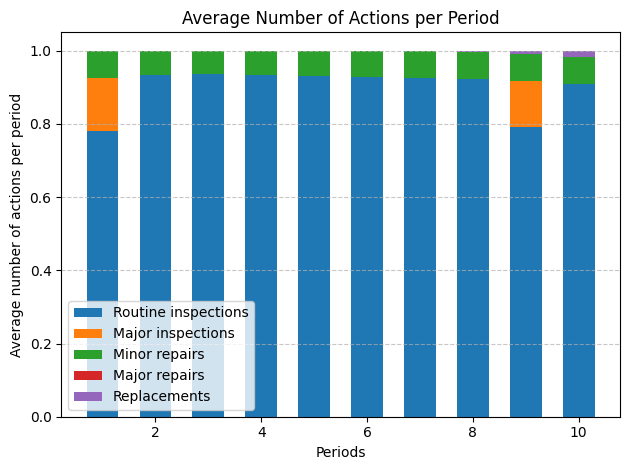

In [6]:
_periods = np.arange(1, len(minor_repairs_per_period) + 1)
bar_width = 0.6

# Stack the bars step by step
plt.bar(
    _periods,
    routine_inspections_per_period,
    width=bar_width,
    label='Routine inspections'
)
plt.bar(
    _periods,
    major_inspections_per_period,
    width=bar_width,
    bottom=routine_inspections_per_period,
    label='Major inspections'
)
plt.bar(
    _periods,
    minor_repairs_per_period,
    width=bar_width,
    bottom=np.array(routine_inspections_per_period)
         + np.array(major_inspections_per_period),
    label='Minor repairs'
)
plt.bar(
    _periods,
    major_repairs_per_period,
    width=bar_width,
    bottom=np.array(routine_inspections_per_period)
         + np.array(major_inspections_per_period)
         + np.array(minor_repairs_per_period),
    label='Major repairs'
)
plt.bar(
    _periods,
    replacements_per_period,
    width=bar_width,
    bottom=np.array(routine_inspections_per_period)
         + np.array(major_inspections_per_period)
         + np.array(minor_repairs_per_period)
         + np.array(major_repairs_per_period),
    label='Replacements'
)

plt.xlabel('Periods')
plt.ylabel('Average number of actions per period')
plt.title('Average Number of Actions per Period')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

### Action Histograms

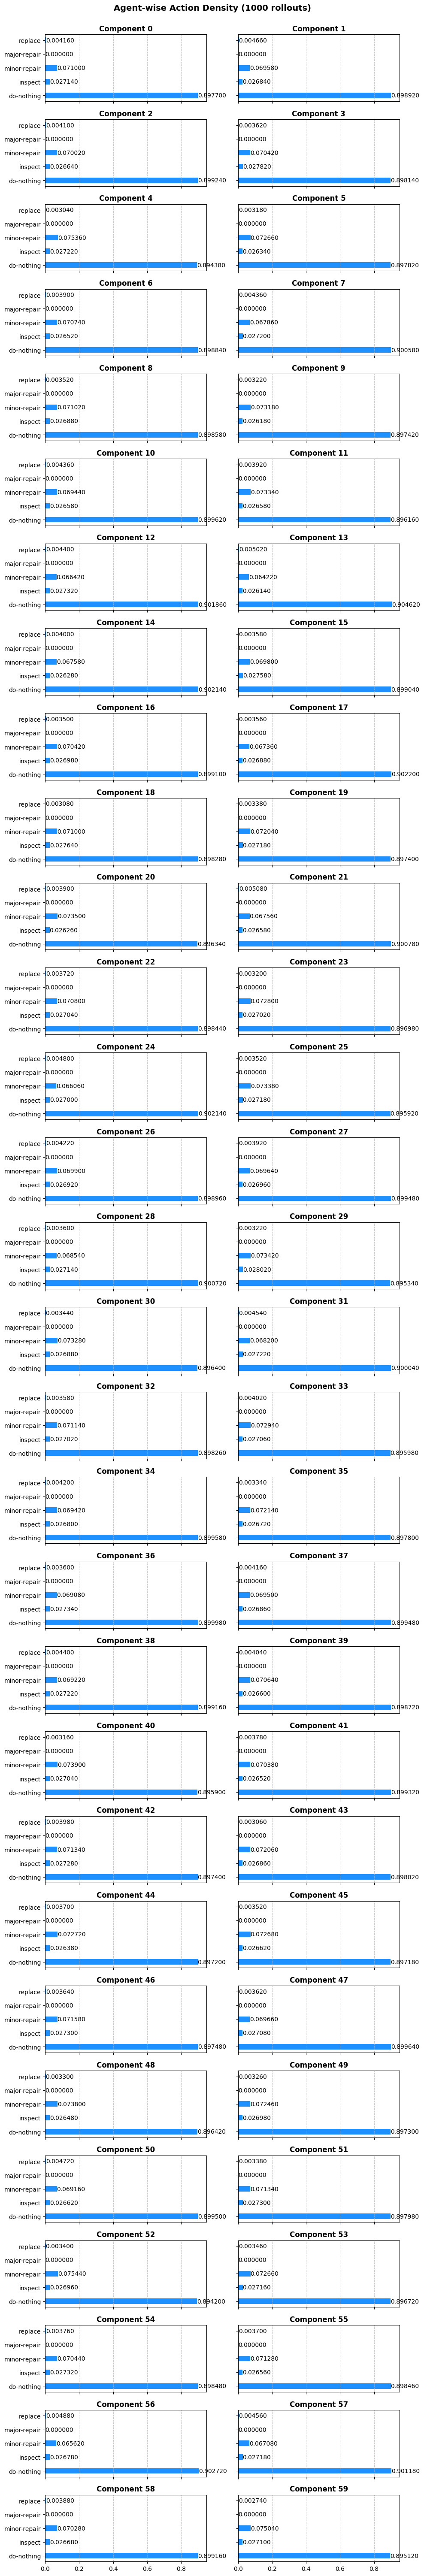

In [8]:
save_fig_kwargs = None

plot_action_stats(episode_data['applied_actions'][:1000], save_kwargs=save_fig_kwargs)

## Analysing Single Episodes

In [9]:
# get data for a single episode among all the episode_data
single_episdode_data = rdg.get_single_episode_data(episode_data, episode_idx=66)

In [10]:
import matplotlib.pyplot as plt

# plt.rcParams.update({
#     'font.size': 8,
#     'font.family': 'serif',
#     'font.serif': ['Times New Roman'],  # or 'Times'
#     'axes.titlesize': 8,
#     'axes.labelsize': 8,
#     'xtick.labelsize': 7,
#     'ytick.labelsize': 7,
#     'legend.fontsize': 7,
# })

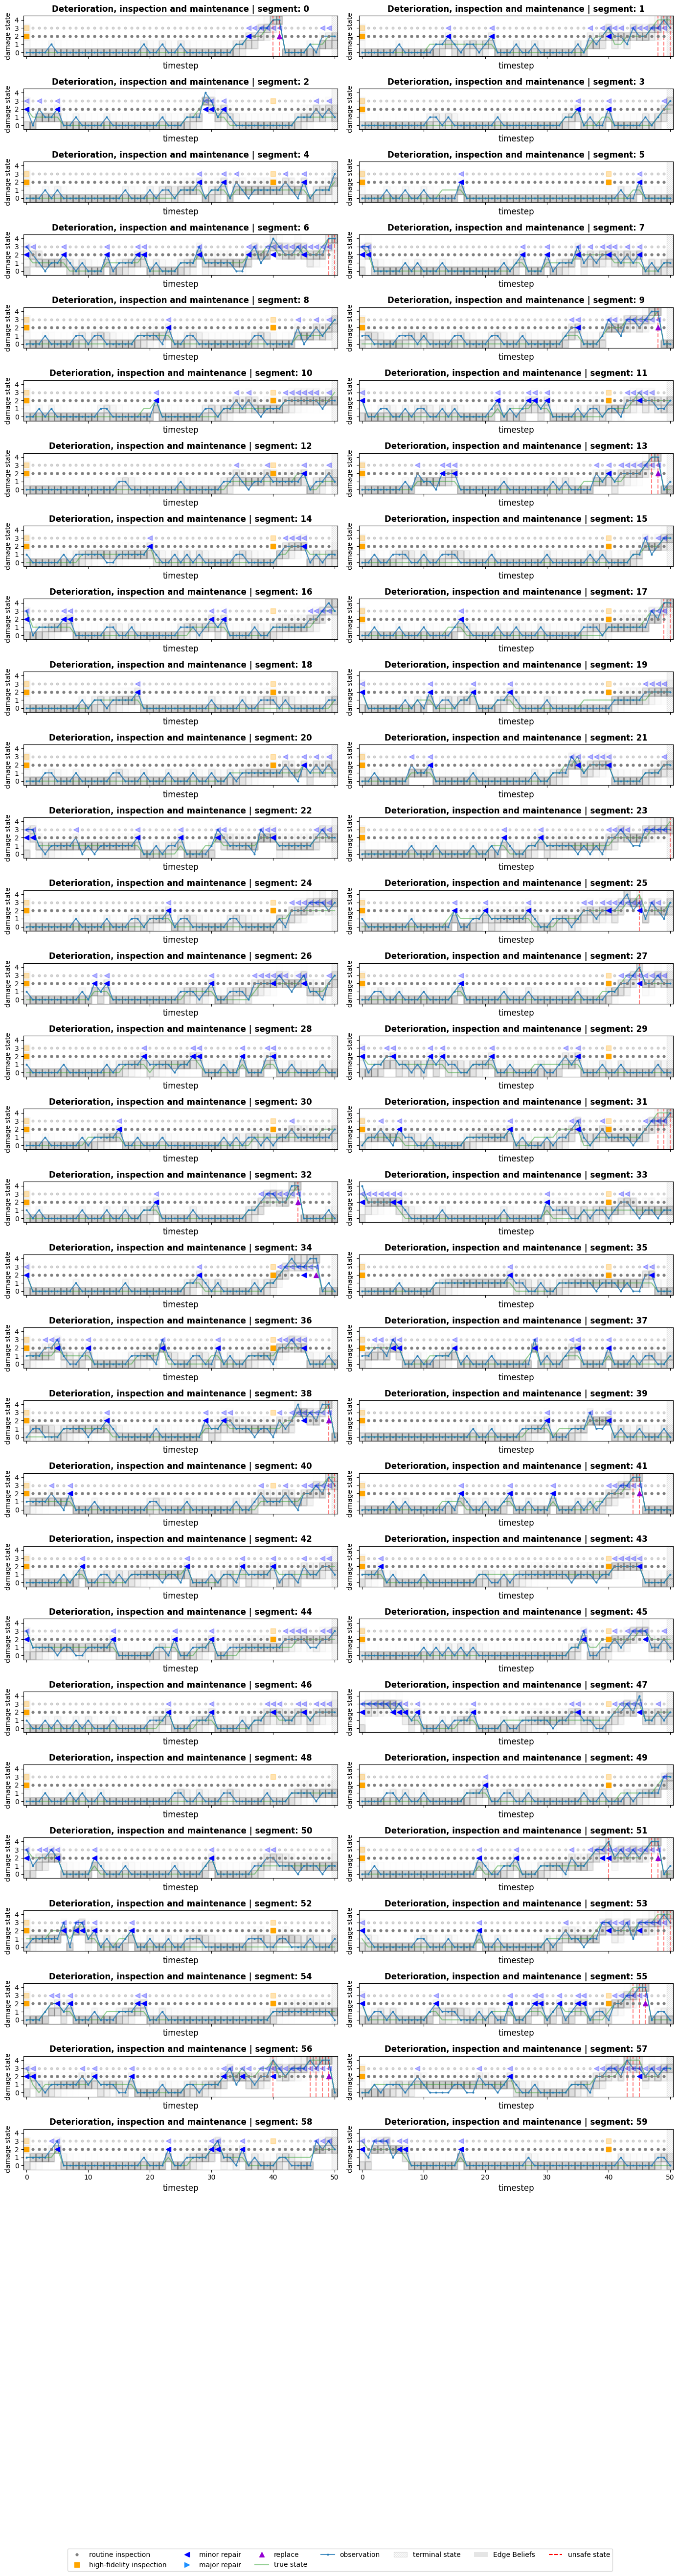

In [11]:
save_fig_kwargs = {
    "fname": "./rollout.pdf",
    "dpi": 300,
    "bbox_inches": "tight",
}
save_fig_kwargs = None

rp._plot_deterioration(single_episdode_data, save_kwargs=save_fig_kwargs)

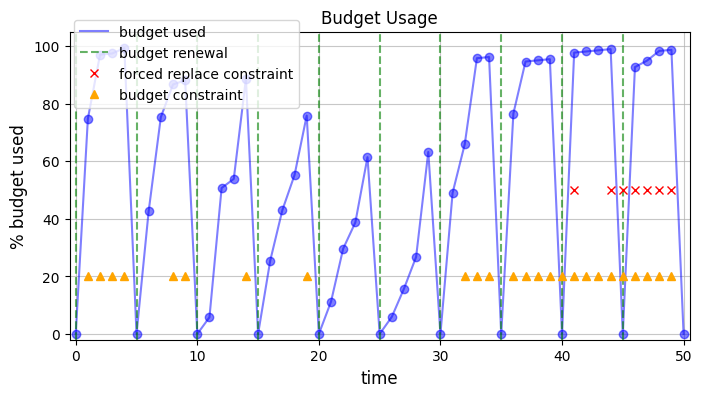

In [12]:
rp._plot_budget(single_episdode_data)

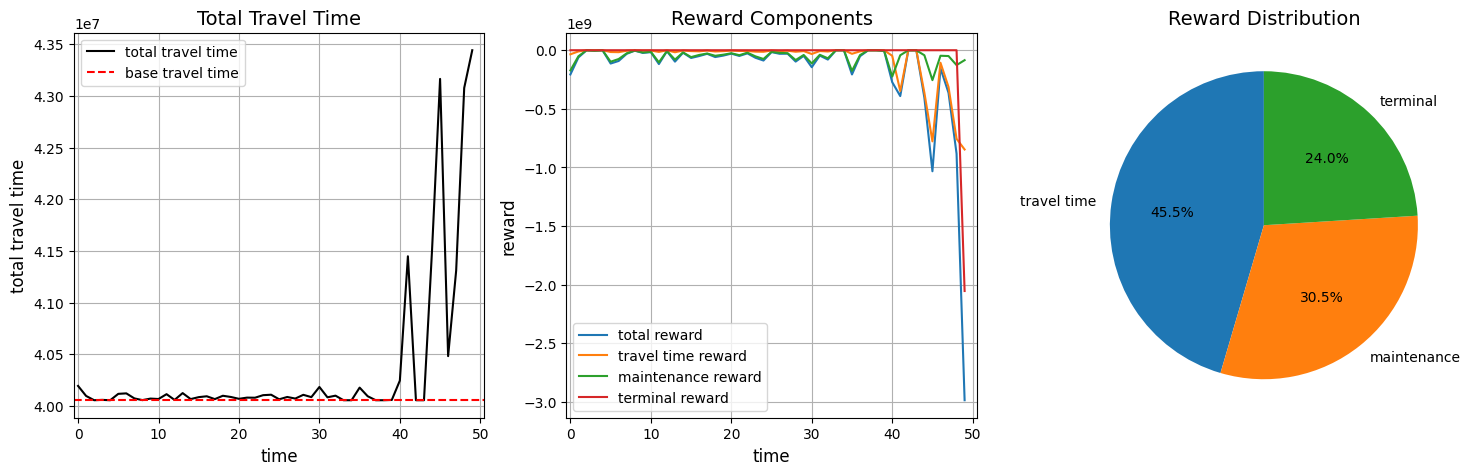

In [13]:
rp._plot_travel_time_and_rewards(single_episdode_data)

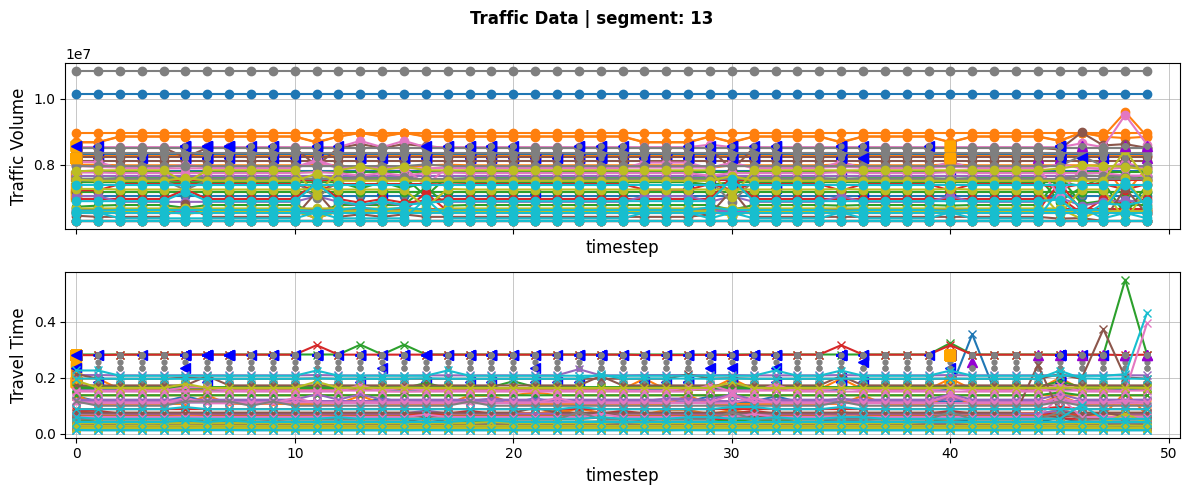

In [14]:
# ToDo: return travel times and traffic volumes in info from jax env
rp._plot_traffic_volume_and_travel_times(single_episdode_data, components_to_show='all')